## Import Libraries

In [21]:
import numpy as np
import meanderpy as mp
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import viridis
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from mpl_toolkits.axes_grid1 import make_axes_locatable
import cmocean
mpl.rcParams['figure.dpi'] = 1000
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

## Kinoshita Initialization and Eulerian Separation Toolkit

In [83]:
# Compute the Kinoshita heading angle θ(s) with amplitude theta0 and wavelength λ
def kinoshita_theta(s, theta0=1.0, lamb=1000.0):
    return theta0 * np.sin(2 * np.pi * s / lamb)

# Construct the Kinoshita centerline (x,y) by integrating the heading θ(s)
# over total_length with n_nodes points. A base_angle can rotate the curve,
# and λ controls the meander wavelength.
def kinoshita_centerline(theta0=1.0, n_nodes=500, total_length=1000.0, base_angle=0.0, lamb=1000.0):
    s = np.linspace(0, total_length, n_nodes)
    theta = kinoshita_theta(s, theta0, lamb) + base_angle
    x = np.zeros_like(s)
    y = np.zeros_like(s)
    for i in range(1, n_nodes):
        ds = s[i] - s[i-1]
        x[i] = x[i-1] + ds * np.cos(theta[i])
        y[i] = y[i-1] + ds * np.sin(theta[i])
    return x, y

# Resample a polyline (x,y) so that successive points are spaced at most ds_target apart.
# Arc length s is computed, then linear interpolation is used to create a densified curve.
def densify_polyline(x, y, ds_target):
    s = np.zeros_like(x)
    s[1:] = np.cumsum(np.hypot(np.diff(x), np.diff(y)))
    n = max(2, int(np.ceil(s[-1]/ds_target)) + 1)
    s_new = np.linspace(0.0, s[-1], n)
    fx = interp1d(s, x, kind="linear")
    fy = interp1d(s, y, kind="linear")
    return fx(s_new), fy(s_new)

# Rasterize a polyline (x,y) into a binary occupancy grid of cell size Δ (delta).
# The domain extent defines the grid bounds. Each segment is subdivided so that
def rasterize_xy(x, y, delta, extent):
    x_min, x_max, y_min, y_max = extent
    nx = int(np.ceil((x_max - x_min)/delta))
    ny = int(np.ceil((y_max - y_min)/delta))
    grid = np.zeros((ny, nx), dtype=np.uint8)
    if len(x) < 2: 
        return grid
    for x0, y0, x1, y1 in zip(x[:-1], y[:-1], x[1:], y[1:]):
        seg_len = np.hypot(x1 - x0, y1 - y0)
        m = max(2, int(np.ceil(seg_len/(0.25*delta))))
        xs = np.linspace(x0, x1, m)
        ys = np.linspace(y0, y1, m)
        cx = ((xs - x_min)/delta).astype(int)
        cy = ((ys - y_min)/delta).astype(int)
        ok = (0 <= cx) & (cx < nx) & (0 <= cy) & (cy < ny)
        grid[cy[ok], cx[ok]] = 1
    return grid

# Build same-extent binary rasters for two channels at timestep t_idx.
# The domain is padded by pad_factor and cell size Δ, then both centerlines
# are densified and rasterized onto that grid for direct comparison.
def channels_to_overlay(chb1, chb2, t_idx, delta, pad_factor=0.05):
    c1, c2 = chb1.channels[t_idx], chb2.channels[t_idx]
    x1, y1 = c1.x, c1.y
    x2, y2 = c2.x, c2.y
    x_all = np.concatenate([x1, x2])
    y_all = np.concatenate([y1, y2])
    xr = x_all.max() - x_all.min()
    yr = y_all.max() - y_all.min()
    pad_x = max(delta, pad_factor * xr)
    pad_y = max(delta, pad_factor * yr)
    extent = (x_all.min()-pad_x, x_all.max()+pad_x, y_all.min()-pad_y, y_all.max()+pad_y)
    ds_target = 0.25 * delta
    xd1, yd1 = densify_polyline(x1, y1, ds_target)
    xd2, yd2 = densify_polyline(x2, y2, ds_target)

    g1 = rasterize_xy(xd1, yd1, delta, extent)
    g2 = rasterize_xy(xd2, yd2, delta, extent)
    return g1, g2, extent

# Visualize two rasterized channels on a black background.
# Red = channel 1 occupancy, Blue = channel 2 occupancy, Purple = overlap
def plot_overlay(g1, g2, extent, title=None):
    ny, nx = g1.shape
    rgb = np.zeros((ny, nx, 3), dtype=float)
    rgb[..., 0] = g1  # red
    rgb[..., 2] = g2  # blue
    fig, ax = plt.subplots(figsize=(6, 3), facecolor="black")
    ax.set_facecolor("black")
    ax.imshow(rgb, origin="lower", extent=extent, interpolation="nearest")
    ax.set_aspect("equal")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    if title:
        ax.set_title(title, color="w")
    ax.tick_params(colors="w")
    for spine in ax.spines.values():
        spine.set_color("w")
    plt.tight_layout()
    plt.show()

# Compute a fixed spatial extent that encloses both channel belts.
# Adds a padding fraction (pad) of the total x- and y-span to ensure margins.
# This keeps the Eulerian grid size consistent across timesteps.
def fixed_extent(chb1, chb2, pad=0.05):
    xs, ys = [], []
    for c in chb1.channels + chb2.channels:
        if c is None:
            continue
        xs.append(c.x)
        ys.append(c.y)
    x_all = np.concatenate(xs)
    y_all = np.concatenate(ys)
    xr = x_all.max() - x_all.min()
    yr = y_all.max() - y_all.min()
    return (x_all.min() - pad * xr, x_all.max() + pad * xr,
            y_all.min() - pad * yr, y_all.max() + pad * yr)

# Compute the log separation series ln d(t) between two channel belts.
# Each timestep is rasterized on a fixed grid (cell size Δ). The separation
# is defined as d(t) = sqrt(# of differing occupied cells) using XOR on the
# binary rasters. Returns ln d(t) (dimensionless) across timesteps.
def ln_distance_series(chb1, chb2, delta, ds_frac=1, t_indices=None, extent=None):
    T = min(len(chb1.channels), len(chb2.channels))
    if t_indices is None:
        t_indices = range(T)
    if extent is None:
        extent = fixed_extent(chb1, chb2, pad=0.05)

    ln_d = np.full(T, np.nan)
    for t in t_indices:
        c1, c2 = chb1.channels[t], chb2.channels[t]
        if (c1 is None) or (c2 is None) or (len(c1.x) < 2) or (len(c2.x) < 2):
            continue

        ds_target = ds_frac * delta
        x1, y1 = densify_polyline(c1.x, c1.y, ds_target)
        x2, y2 = densify_polyline(c2.x, c2.y, ds_target)

        g1 = rasterize_xy(x1, y1, delta, extent).astype(np.uint8)
        g2 = rasterize_xy(x2, y2, delta, extent).astype(np.uint8)

        n_diff = np.count_nonzero(np.bitwise_xor(g1, g2))

        ln_d[t] = 0.0 if n_diff == 0 else 0.5 * np.log(float(n_diff))

    return ln_d, extent

## Kinoshita Channel Initialization with Reference and Perturbed Centerlines

The parameter `perturbationsize` defines the magnitude of the imposed perturbation (Figure 3 in the paper). By default, it is added at the midpoint (`mid_idx`), but the perturbation can be applied at any node by adjusting the index.


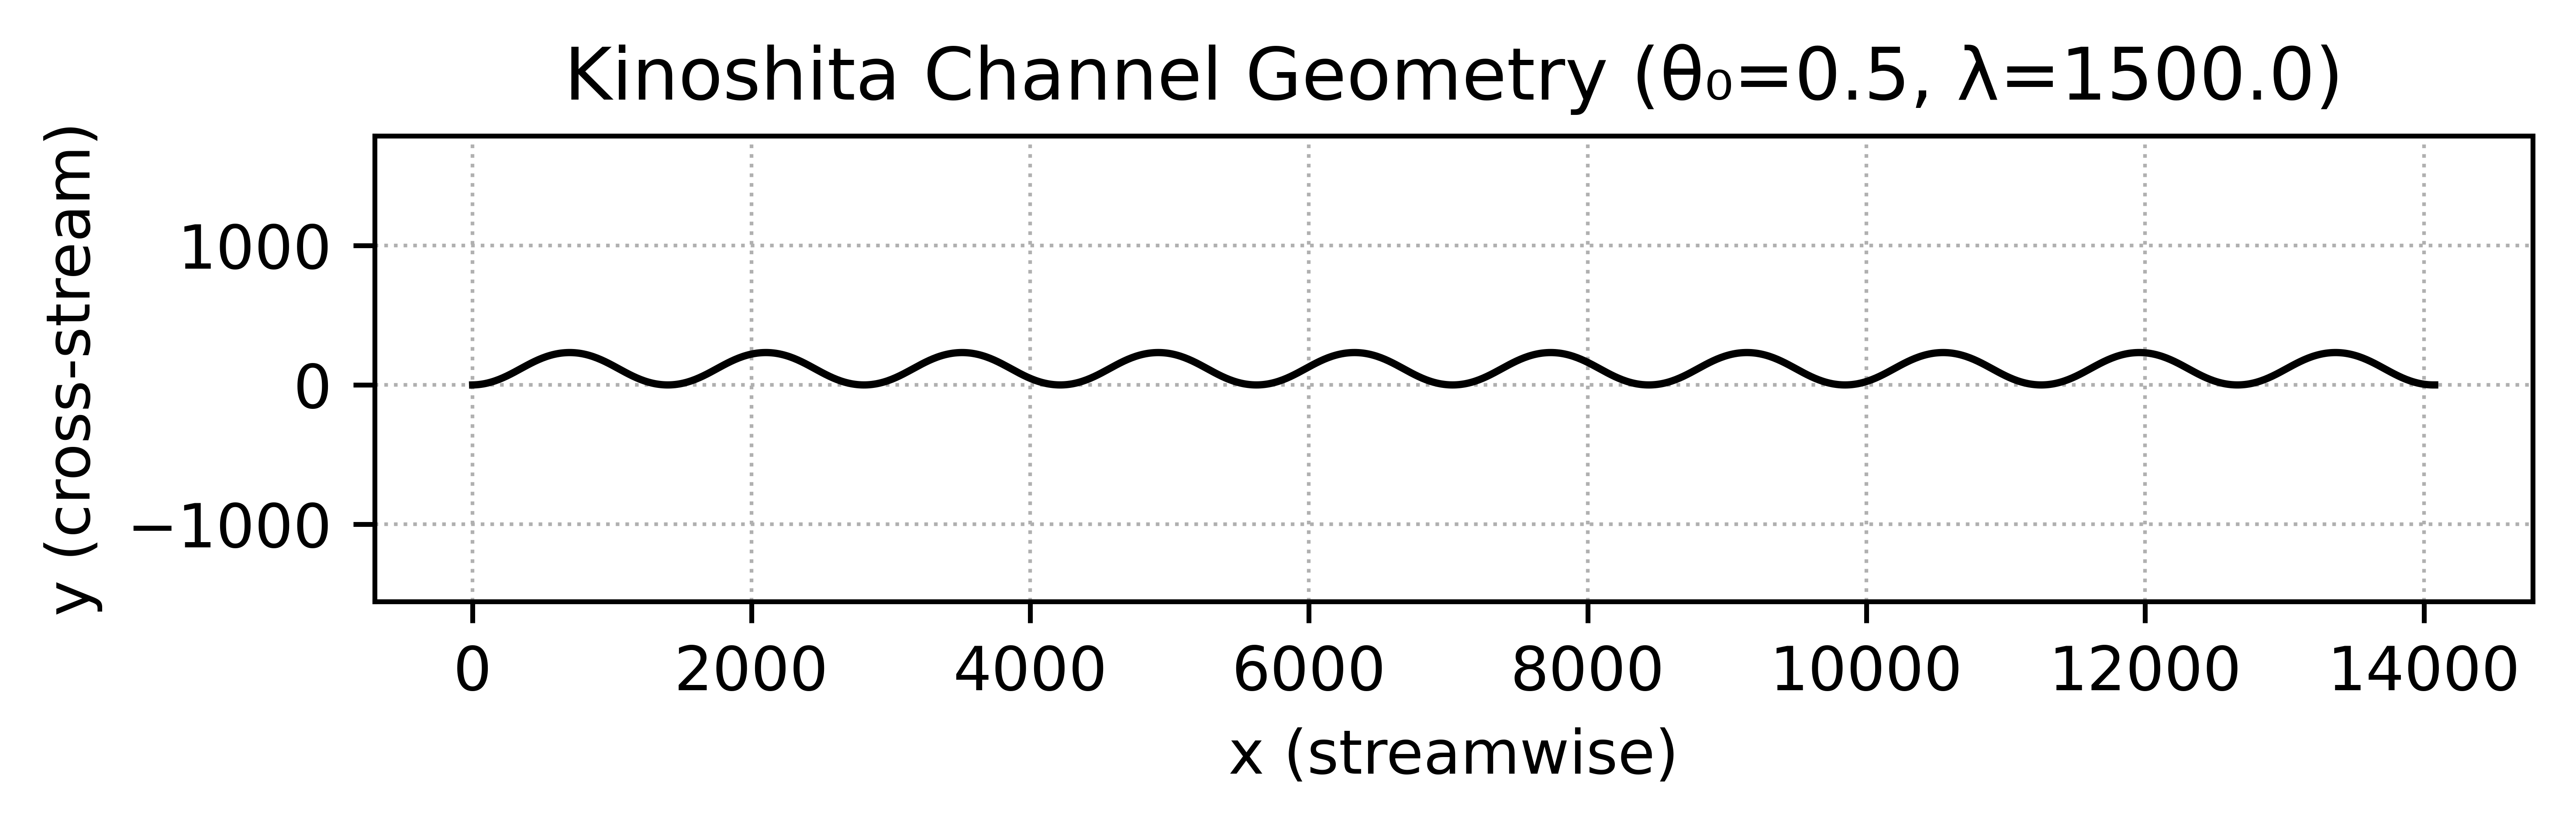

In [ ]:
theta0 = 0.5
lamb = 1500.0
n_nodes = 1000
total_length = 15000.0
base_angle = 0.0
perturbationsize = 1e-10

x1, y1 = kinoshita_centerline(theta0=theta0, n_nodes=n_nodes, total_length=total_length, base_angle=base_angle, lamb=lamb)
x2, y2 = x1.copy(), y1.copy()
mid_idx = len(y2) // 2
y2[mid_idx] += perturbationsize
z1 = np.zeros_like(x1)
z2 = np.zeros_like(x2)

x_ref, y_ref = kinoshita_centerline(theta0=theta0,
                                    n_nodes=n_nodes,
                                    total_length=total_length,
                                    base_angle=base_angle,
                                    lamb=lamb)

# Plot initial geometry
plt.figure(figsize=(6, 2))
plt.plot(x_ref, y_ref, 'k-', lw=1.2)
plt.xlabel("x (streamwise)")
plt.ylabel("y (cross-stream)")
plt.title(f"Kinoshita Channel Geometry (θ₀={theta0}, λ={lamb})")
plt.axis("equal")
plt.grid(True, ls=":", lw=0.6)
plt.tight_layout()
plt.show()

## Define Parameters and Run *meanderpy*

The parameter `crdist` controls the cutoff threshold $d_c$, which determines whether channel intersections trigger cutoffs. Setting `crdist = 0` disables cutoff dynamics, so channels may intersect without cutoff events.


In [86]:
# --- meanderpy run parameters (units shown) ---
nit       = 5000                  # iterations (time steps)
W         = 50.0                  # channel width (m)
D         = 1.0                   # channel depth (m)
depths    = D * np.ones((nit,))   # depth at each time step (m)
pad       = 0                     # centerline padding nodes (up/downstream)
deltas    = 100.0                 # along-centerline sampling distance (m)
Cfs       = 0.0061 * np.ones((nit,))  # dimensionless friction factor (Chezy-like)
crdist    = 5 * W                 # cutoff threshold distance d_c (m); set 0 to disable cutoffs
kl        = 100/(365*24*60*60.0)  # lateral migration rate constant (m/s)
kv        = 0                     # vertical slope-dependent erosion rate (m/s)
dt        = 0.1*(365*24*60*60.0)  # time step (s)
dens      = 1000                  # water density (kg/m^3)
saved_ts  = 1                     # save every Nth step (stride)
Sl        = 0.0                   # initial bed slope (dimensionless)
t1        = 0                     # onset time index for incision phase
t2        = 0                     # onset time index for lateral-migration phase
t3        = 1200                  # onset time index for aggradation phase
aggr_factor = 2e-9                # aggradation rate (m/s)
H         = depths[0]             # initial flow depth passed to Channel (m)

ch1 = mp.Channel(x1, y1, z1, W, H)
chb1 = mp.ChannelBelt(channels=[ch1], cutoffs=[], cl_times=[0.0], cutoff_times=[])
ch2 = mp.Channel(x2, y2, z2, W, H)
chb2 = mp.ChannelBelt(channels=[ch2], cutoffs=[], cl_times=[0.0], cutoff_times=[])
chb1.migrate(nit, saved_ts, deltas, pad, crdist, depths, Cfs, kl, kv, dt, dens, t1, t2, t3, aggr_factor)
chb2.migrate(nit, saved_ts, deltas, pad, crdist, depths, Cfs, kl, kv, dt, dens, t1, t2, t3, aggr_factor)

100%|██████████| 5000/5000 [00:06<00:00, 752.59it/s]


## Lagrangian Channel Geometry: Reference vs. Perturbed

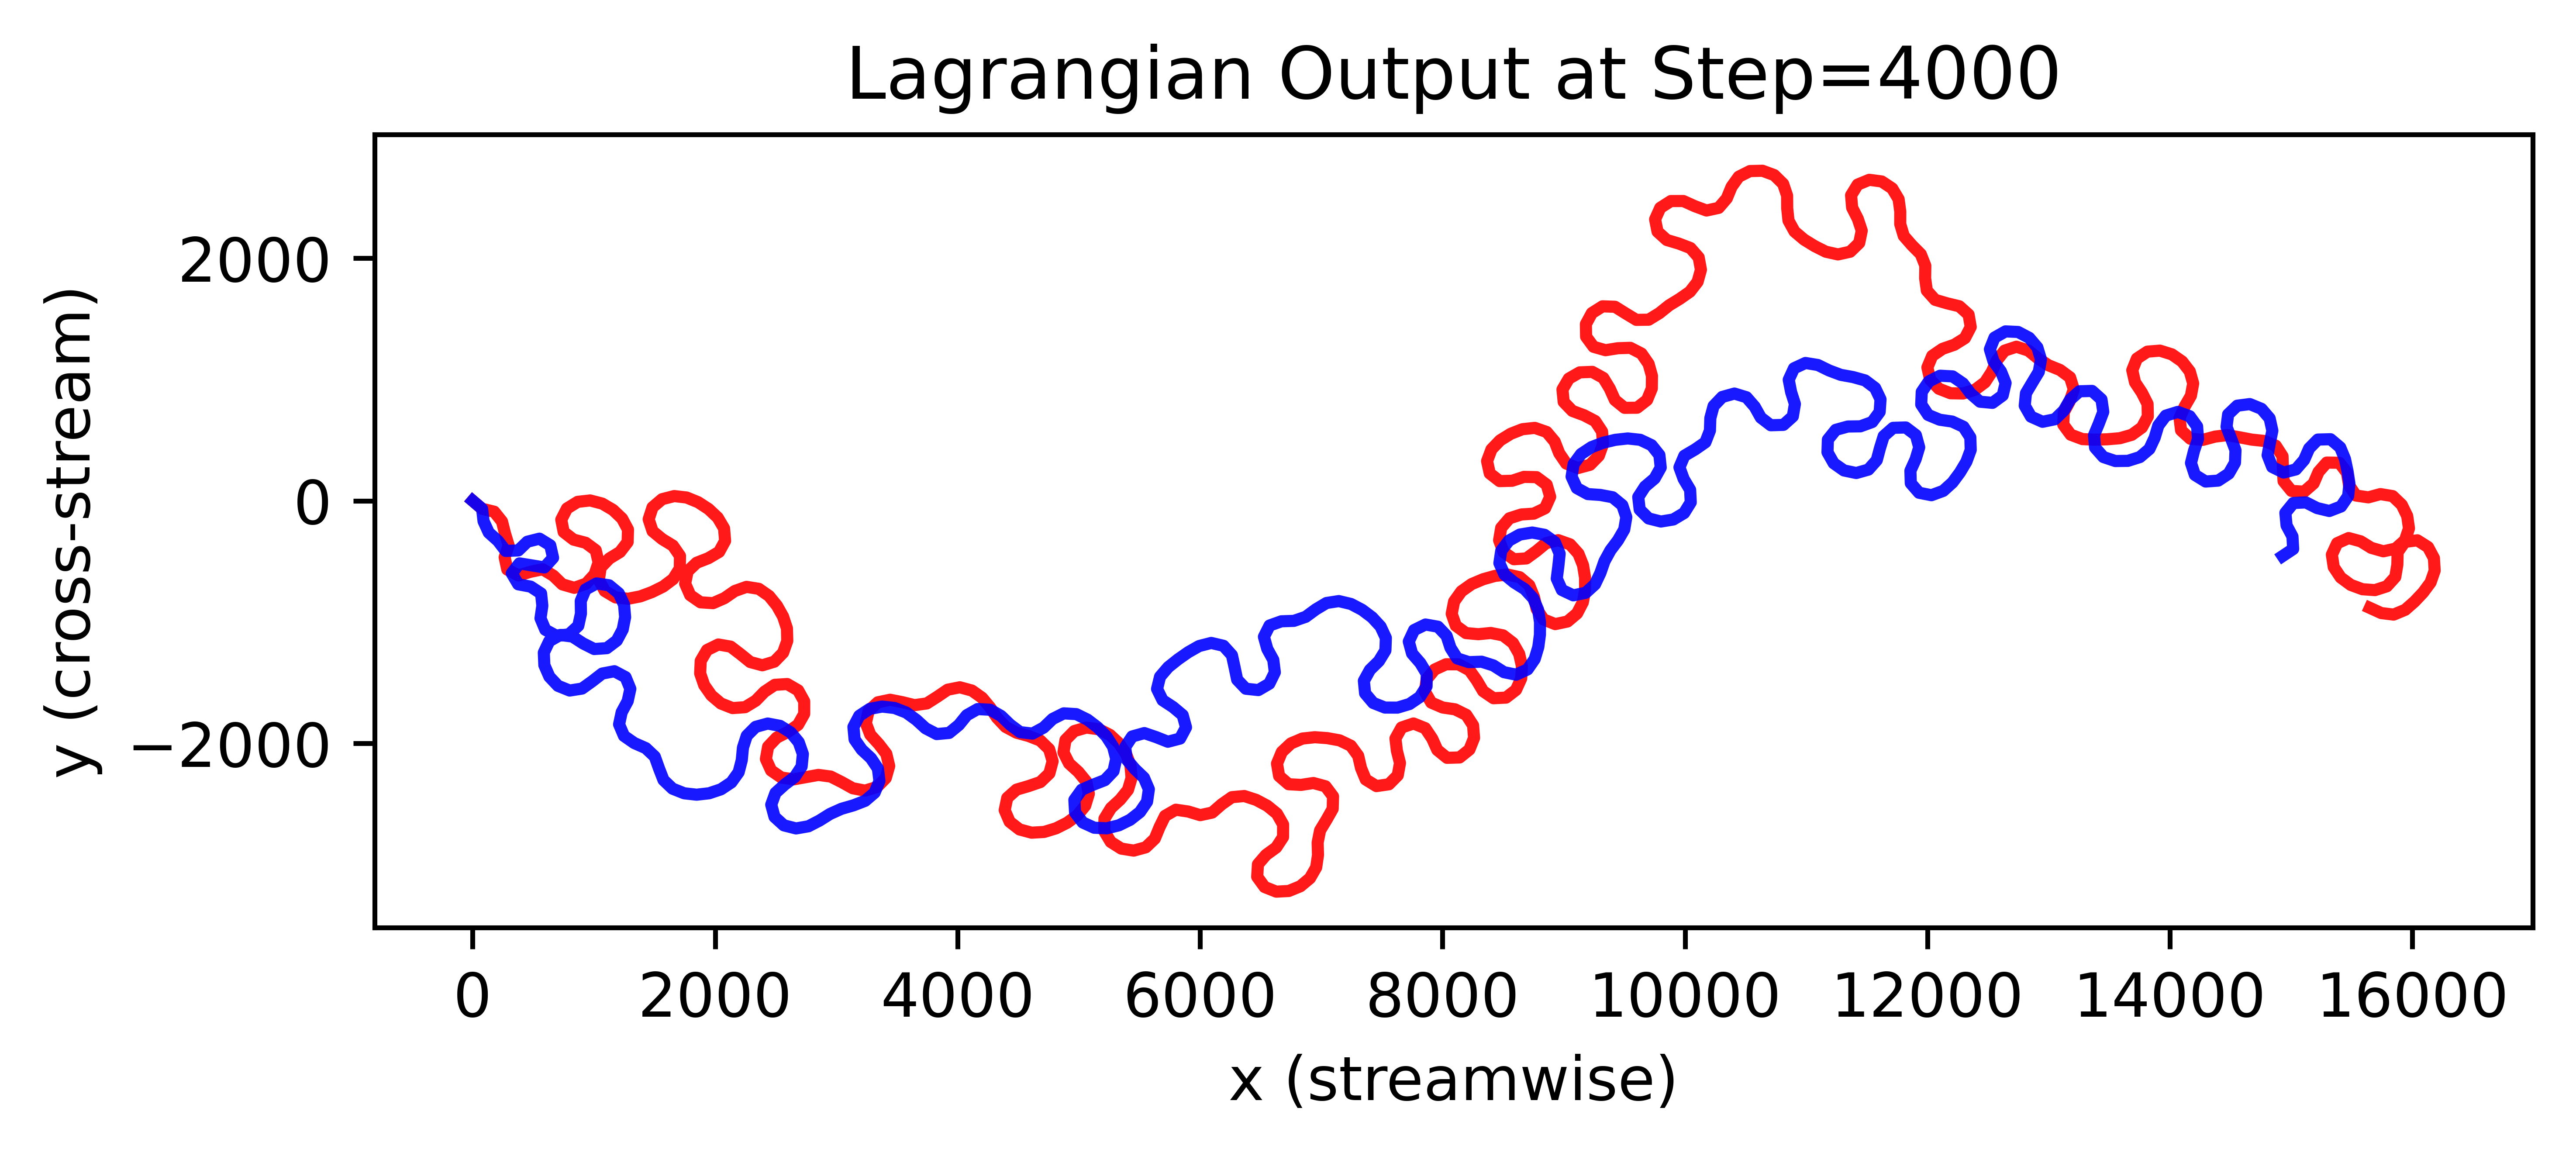

In [87]:
t_idx = 4000 # timestep of the output
fig, ax = plt.subplots(figsize=(6,3))
ax.plot(chb1.channels[t_idx].x, chb1.channels[t_idx].y,
        lw=2, color='red', alpha=0.9, label="Unperturbed")
ax.plot(chb2.channels[t_idx].x, chb2.channels[t_idx].y,
        lw=2, color='blue', alpha=0.9, linestyle="-", label="Perturbed")
ax.set_xlabel("x (streamwise)")
ax.set_ylabel("y (cross-stream)")
ax.set_title(f"Lagrangian Output at Step={t_idx}")
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

## Eulerian Channel Occupancy Fields

The parameter `delta` sets the grid cell size $\Delta$, which fixes the resolution of the Eulerian state. At each timestep $t$, both the reference and perturbed channel centerlines are densified and rasterized into binary occupancy fields on the same grid extent. The fields $\mathbf{S}(t)$ (reference) and $\mathbf{S}^\ast(t)$ (perturbed) are then overlaid: red marks cells occupied only by the reference channel, blue marks cells occupied only by the perturbed channel, and purple highlights overlap where both trajectories occupy the same cells.


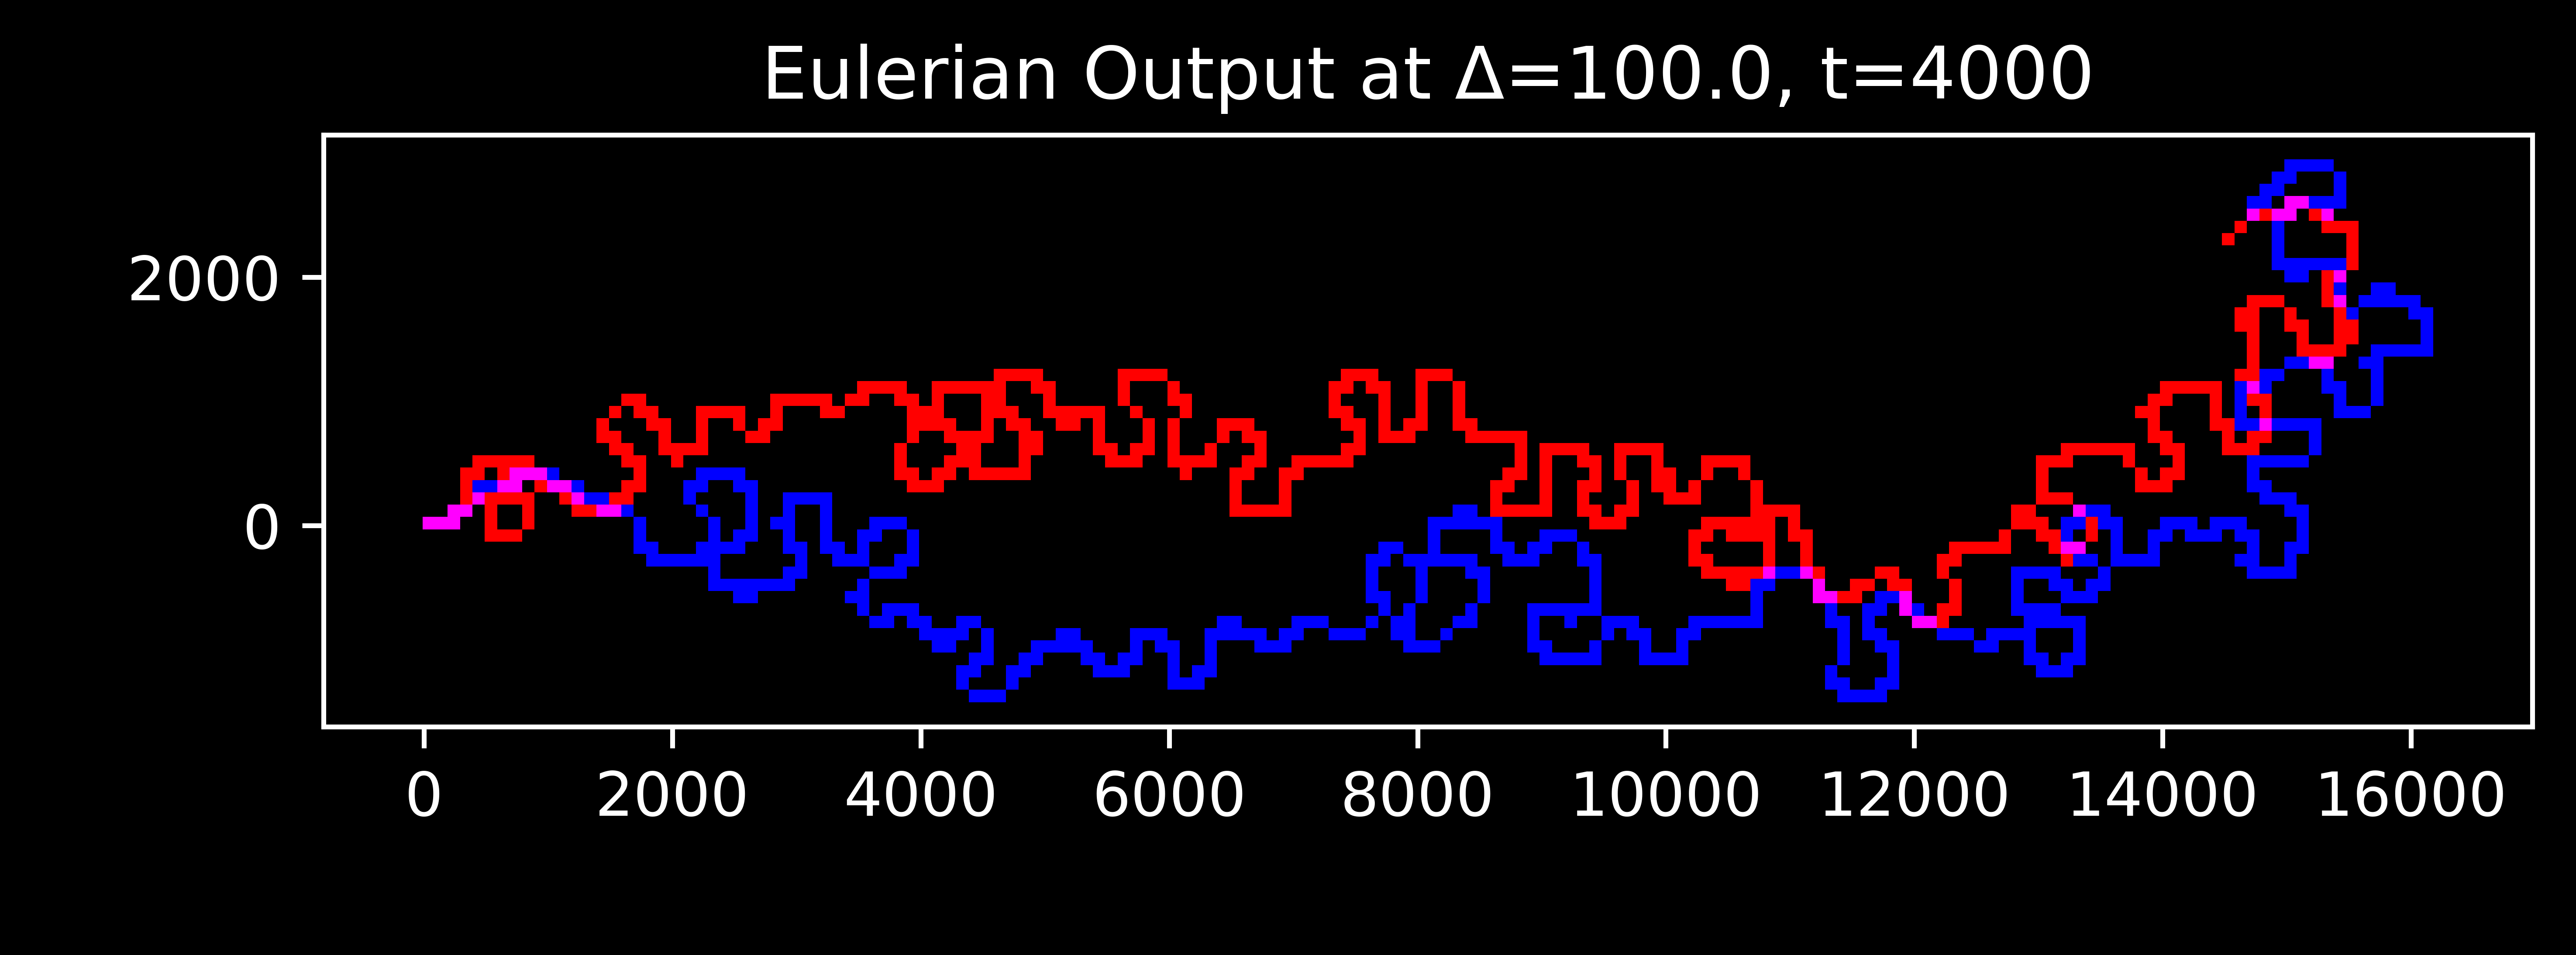

In [80]:
delta  = 100.0 # size of the grid    
t_idx  = 4000 # timestep of the output
g1, g2, extent = channels_to_overlay(chb1, chb2, t_idx, delta)
plot_overlay(g1, g2, extent, title=f"Eulerian Output at Δ={delta}, t={t_idx}")

## Eulerian Log Separation Series

The plot shows the time series of $\ln d(t)$, where $d(t)$ is the binary-grid separation between reference and perturbed channels. Smaller $\Delta$ values yield finer grids (more sensitive to geometric differences), while larger $\Delta$ values coarsen the state space and smooth out differences.


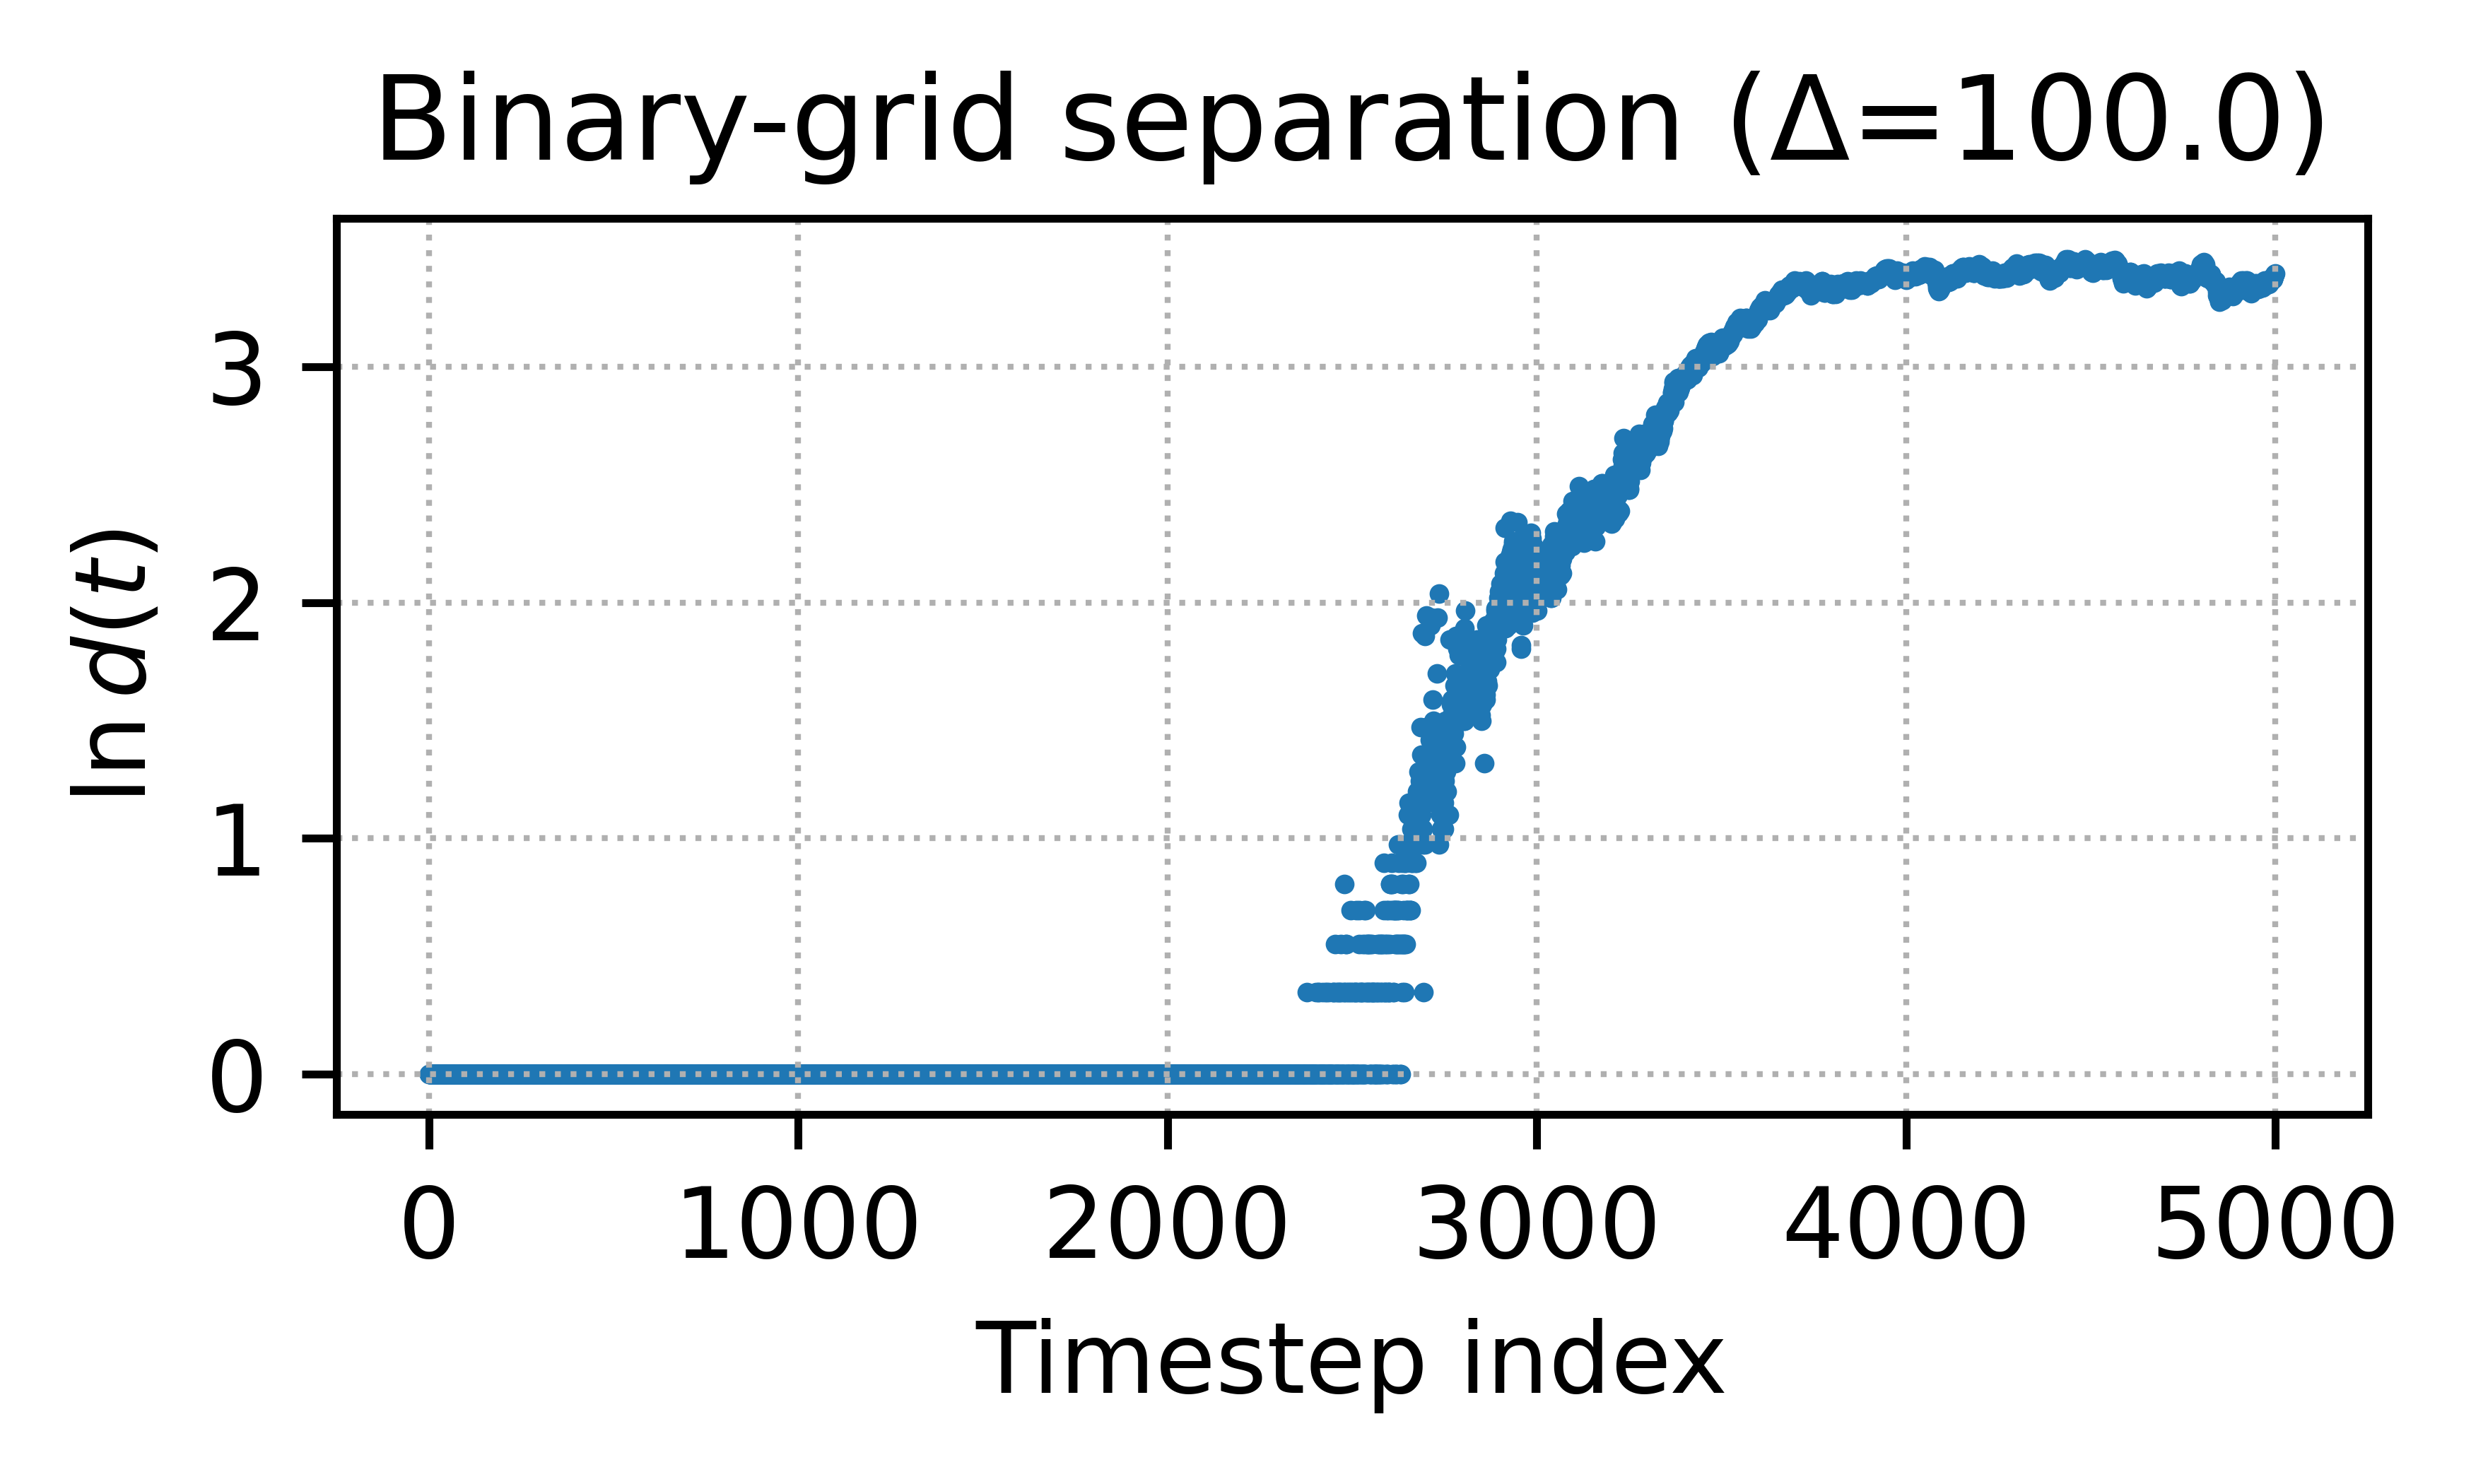

In [79]:
delta = 100.0 
ln_d, extent = ln_distance_series(chb1, chb2, delta=delta, ds_frac=1)
t_idx = np.arange(len(ln_d))
plt.figure(figsize=(3.6, 2.2))
mask = ~np.isnan(ln_d)
plt.scatter(t_idx[mask], ln_d[mask], s=1)
plt.xlabel("Timestep index")
plt.ylabel(r"$\ln d(t)$")
plt.title(f"Binary-grid separation (Δ={delta})")
plt.grid(True, ls=":", lw=0.6)
plt.tight_layout()
plt.show()